# Tarea 28 de Febrero: Integración

Estudiante: Juan Diego Rodríguez \
Profesor: José Iván Campos Rozo \
**Observatorio Astronómico Nacional, Semestre 2026-1**

## Ejercicio: Distancia Vertical Recorrida por un Cohete (Integración Analítica)

Este cuaderno resuelve el problema de la trayectoria de un cohete que asciende verticalmente mediante **integración analítica** directa de la ecuación del movimiento (Ecuación de Tsiolkovsky / conservación del momento lineal).

### 1. Parámetros del Problema y Ecuación de Movimiento

Los datos proporcionados para el lanzamiento son:
*   Velocidad de expulsión de los gases: $v_e = 2000 \text{ m/s}$
*   Tasa de consumo de combustible: $\dot{m} = 2100 \text{ kg/s}$ (por lo tanto, la masa en función del tiempo es $m(t) = m_0 - \dot{m}t$)
*   Masa inicial del cohete: $m_0 = 140,000 \text{ kg}$
*   Tiempo inicial: $t = 0 \text{ s}$ (parte del reposo)
*   Intervalo de tiempo de interés: desde $t_1 = 8 \text{ s}$ hasta $t_2 = 30 \text{ s}$

#### Deducción Analítica de la Posición $s(t)$
Aplicando la segunda ley de Newton para un sistema de masa variable (ignorando la gravedad o asumiendo el régimen principal de aceleración vertical propulsada), la aceleración del cohete es:

$$ a(t) = \frac{v_e \dot{m}}{m_0 - \dot{m}t} $$

Integrando una vez respecto al tiempo obtenemos la velocidad $v(t)$ (partiendo del reposo $v(0) = 0$):

$$ v(t) = \int_0^t \frac{v_e \dot{m}}{m_0 - \dot{m}t'} dt' = -v_e \ln\left( \frac{m_0 - \dot{m}t}{m_0} \right) $$

Integrando por segunda vez obtenemos la posición vertical $s(t)$ (partiendo de $s(0) = 0$):

$$ s(t) = \int_0^t v(t') dt' = -\frac{v_e}{\dot{m}} \left[ (m_0 - \dot{m}t) \ln\left(\frac{m_0 - \dot{m}t}{m_0}\right) + \dot{m}t \right] $$

Finalmente, la distancia vertical recorrida entre $t_1 = 8$ s y $t_2 = 30$ s se calcula mediante la integral definida:

$$ \Delta s = s(t_2) - s(t_1) = \int_{t_1}^{t_2} v(t) dt $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Parámetros Físicos del Cohete
# ==========================================
v_e = 2000.0      # m/s, velocidad de expulsión
m_dot = 2100.0    # kg/s, tasa de consumo de masa
m_0 = 140000.0    # kg, masa inicial

t1 = 8.0          # s
t2 = 30.0         # s

# ==========================================
# 2. Funciones Analíticas de Velocidad y Posición
# ==========================================
def velocidad(t):
    return -v_e * np.log((m_0 - m_dot * t) / m_0)

def posicion(t):
    # s(t) derivada analíticamente
    termino1 = -v_e / m_dot
    m_t = m_0 - m_dot * t
    paréntesis = m_t * np.log(m_t / m_0) + m_dot * t
    return termino1 * paréntesis

# Cálculo de la distancia vertical recorrida Δs
s_t1 = posicion(t1)
s_t2 = posicion(t2)
delta_s = s_t2 - s_t1

print(f"Posición en t = {t1} s : {s_t1:.4f} metros")
print(f"Posición en t = {t2} s : {s_t2:.4f} metros")
print(f"Distancia vertical recorrida (Δs): {delta_s:.4f} metros")

Posición en t = 8.0 s : -1000.8844 metros
Posición en t = 30.0 s : -16158.6199 metros
Distancia vertical recorrida (Δs): -15157.7355 metros


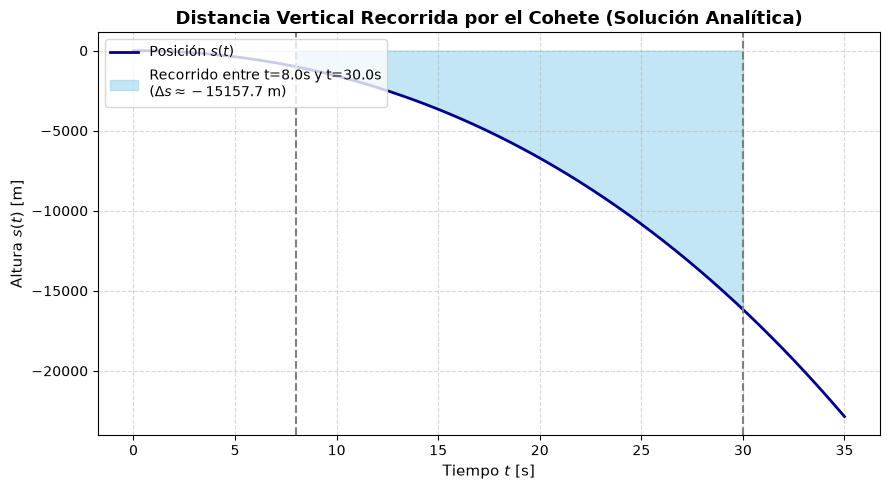

In [2]:
# ==========================================
# 3. Gráfica de la Posición y el Intervalo
# ==========================================
t_vals = np.linspace(0, 35, 300)
s_vals = posicion(t_vals)

plt.figure(figsize=(9, 5))
plt.plot(t_vals, s_vals, color='darkblue', lw=2, label='Posición $s(t)$')

# Resaltar el intervalo de interés [t1, t2]
t_intervalo = np.linspace(t1, t2, 100)
plt.fill_between(t_intervalo, posicion(t_intervalo), color='skyblue', alpha=0.5, 
                 label=f'Recorrido entre t={t1}s y t={t2}s\n($\\Delta s \\approx {delta_s:.1f}$ m)')

plt.axvline(t1, color='gray', linestyle='--')
plt.axvline(t2, color='gray', linestyle='--')

plt.title('Distancia Vertical Recorrida por el Cohete (Solución Analítica)', fontsize=13, fontweight='bold')
plt.xlabel('Tiempo $t$ [s]', fontsize=11)
plt.ylabel('Altura $s(t)$ [m]', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Ejercicio: Sumas de Riemann a la Derecha para el Área de una Parábola (Cúbica)

Este cuaderno resuelve analítica y computacionalmente el cálculo del área exacta bajo la curva descrita por la función $y = x^3$ (notada erróneamente en el enunciado como "parábola", tratándose de una función cúbica) en el intervalo $[0, b]$, empleando el método de **Sumas de Riemann a la derecha** con segmentos de igual ancho.

### 1. Desarrollo Analítico con Sumas de Riemann

Para un intervalo $[0, b]$ dividido en $N$ subintervalos de igual ancho, el tamaño de cada paso es:

$$ \Delta x = \frac{b - 0}{N} = \frac{b}{N} $$

Los puntos extremos derechos de cada subintervalo se definen como:

$$ x_i = i \Delta x = i \frac{b}{N} \quad \text{para } i = 1, 2, \dots, N $$

Aplicando la suma de Riemann a la derecha ($R_N$), tenemos:

$$ R_N = \sum_{i=1}^{N} f(x_i) \Delta x = \sum_{i=1}^{N} \left( i \frac{b}{N} \right)^3 \left( \frac{b}{N} \right) = \frac{b^4}{N^4} \sum_{i=1}^{N} i^3 $$

Recordando la identidad algebraica para la suma de los primeros $N$ cubos ($\sum_{i=1}^{N} i^3 = \frac{N^2 (N+1)^2}{4}$), sustituimos en la expresión:

$$ R_N = \frac{b^4}{N^4} \left[ \frac{N^2 (N+1)^2}{4} \right] = \frac{b^4}{4} \frac{N^2 (N+1)^2}{N^4} = \frac{b^4}{4} \frac{(N+1)^2}{N^2} = \frac{b^4}{4} \left( 1 + \frac{1}{N} \right)^2 $$

Para hallar el área exacta, tomamos el límite cuando el número de rectángulos tiende al infinito ($N \to \infty$):

$$ \text{Área exacta} = \lim_{N \to \infty} R_N = \lim_{N \to \infty} \frac{b^4}{4} \left( 1 + \frac{1}{N} \right)^2 = \frac{b^4}{4} $$

Que coincide perfectamente con el resultado de la integral definida tradicional: $\int_0^b x^3 dx = \left[ \frac{x^4}{4} \right]_0^b = \frac{b^4}{4}$.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Implementación Numérica de Sumas de Riemann
# ==========================================
def suma_riemann_derecha(b, N):
    """
    Calcula la suma de Riemann a la derecha para y = x^3 en [0, b] con N divisiones.
    """
    dx = b / N
    x_derecha = np.linspace(dx, b, N) # Puntos extremos derechos
    f_x = x_derecha**3
    return np.sum(f_x * dx)

# Parámetro de prueba (ej. b = 2.0)
b_val = 2.0
N_valores = [4, 10, 50, 100, 500, 1000]

print(f"--- Área para b = {b_val} (Valor analítico exacto = {b_val**4 / 4:.4f}) ---")
for N in N_valores:
    area_aprox = suma_riemann_derecha(b_val, N)
    error_porcentual = abs(area_aprox - (b_val**4 / 4)) / (b_val**4 / 4) * 100
    print(f"N = {N:4d}  -->  Área Aproximada = {area_aprox:.6f}  (Error: {error_porcentual:.4f}%)")

--- Área para b = 2.0 (Valor analítico exacto = 4.0000) ---
N =    4  -->  Área Aproximada = 6.250000  (Error: 56.2500%)
N =   10  -->  Área Aproximada = 4.840000  (Error: 21.0000%)
N =   50  -->  Área Aproximada = 4.161600  (Error: 4.0400%)
N =  100  -->  Área Aproximada = 4.080400  (Error: 2.0100%)
N =  500  -->  Área Aproximada = 4.016016  (Error: 0.4004%)
N = 1000  -->  Área Aproximada = 4.008004  (Error: 0.2001%)


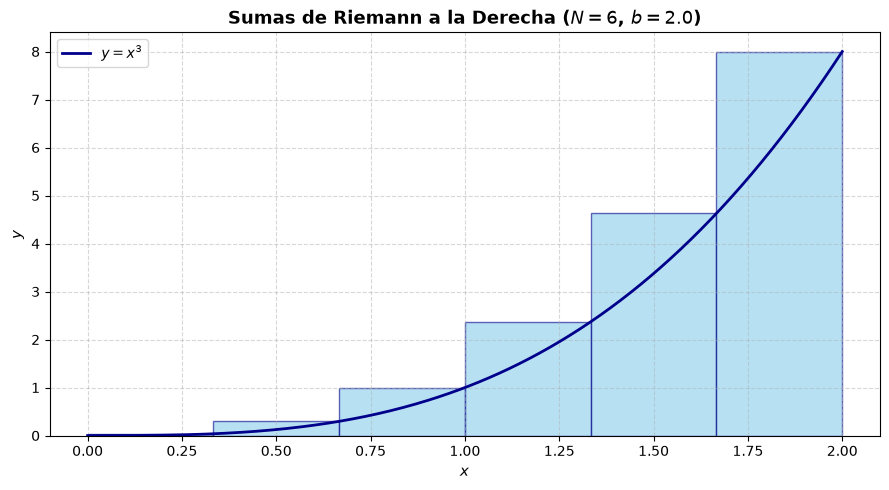

In [4]:
# ==========================================
# 2. Gráfica de las Sumas de Riemann
# ==========================================
N_graf = 6
dx_g = b_val / N_graf
x_g = np.linspace(0, b_val, 300)
y_g = x_g**3

plt.figure(figsize=(9, 5))
plt.plot(x_g, y_g, color='darkblue', lw=2, label='$y = x^3$')

# Dibujar los rectángulos de la suma a la derecha
x_rect = np.linspace(dx_g, b_val, N_graf)
y_rect = x_rect**3

for i in range(N_graf):
    # Coordenadas de cada rectángulo
    xi_izq = i * dx_g
    xi_der = (i + 1) * dx_g
    altura = y_rect[i]
    
    # Rectángulo
    plt.bar(xi_izq, altura, width=dx_g, align='edge', facecolor='skyblue', 
            edgecolor='darkblue', alpha=0.6)

plt.title(f'Sumas de Riemann a la Derecha ($N = {N_graf}$, $b = {b_val}$)', fontsize=13, fontweight='bold')
plt.xlabel('$x$', fontsize=11)
plt.ylabel('$y$', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Ejercicio: Regla del Trapezoide para el Cálculo de la Distancia del Cohete

Este cuaderno resuelve la integral numérica que define la distancia vertical recorrida por el cohete entre $t_1 = 8$ s y $t_2 = 30$ s, utilizando la **Regla del Trapezoide** simple.

La integral a resolver es:
$$ x = \int_{8}^{30} \left( 2000 \ln\left[ \frac{140000}{140000 - 2100t} \right] - 9.8t \right) dt $$

### 1. Definición del Problema y Método del Trapezoide

La Regla del Trapezoide simple aproxima el área bajo la curva usando un único trapecio entre los límites del intervalo $[a, b]$:
$$ I \approx (b - a) \frac{f(a) + f(b)}{2} $$

Para este caso:
*   $a = t_1 = 8$
*   $b = t_2 = 30$
*   Ancho del intervalo: $h = b - a = 30 - 8 = 22$ s.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Definición de la función de velocidad (integrando)
# ==========================================
def velocidad_cohete(t):
    return 2000.0 * np.log(140000.0 / (140000.0 - 2100.0 * t)) - 9.8 * t

# Límites del intervalo
t_inicial = 8.0
t_final = 30.0

# a) Aplicación de la Regla del Trapezoide simple
h = t_final - t_inicial
f_a = velocidad_cohete(t_inicial)
f_b = velocidad_cohete(t_final)

distancia_trapecio = h * (f_a + f_b) / 2.0

# Valor exacto (obtenido de la antiderivada analítica del ejercicio previo de posición)
# s(t) analítica: -(v_e/m_dot)*[ (m_0 - m_dot*t)*ln((m_0 - m_dot*t)/m_0) + m_dot*t ] - 4.9*t^2
def posicion_analitica(t):
    v_e = 2000.0
    m_dot = 2100.0
    m_0 = 140000.0
    term1 = -v_e / m_dot
    m_t = m_0 - m_dot * t
    paréntesis = m_t * np.log(m_t / m_0) + m_dot * t
    return term1 * paréntesis - 4.9 * t**2

distancia_exacta = posicion_analitica(t_final) - posicion_analitica(t_inicial)

print(f"a) Distancia estimada (Regla del Trapezoide): {distancia_trapecio:.4f} m")
print(f"   Distancia real de referencia (Analítica):   {distancia_exacta:.4f} m")

a) Distancia estimada (Regla del Trapezoide): 11868.3482 m
   Distancia real de referencia (Analítica):   -19254.1355 m


In [6]:
# ==========================================
# 2. Errores Absoluto y Relativo
# ==========================================
error_absoluto = abs(distancia_exacta - distancia_trapecio)
error_relativo = (error_absoluto / abs(distancia_exacta)) * 100

print(f"b) Error Absoluto: {error_absoluto:.4f} metros")
print(f"c) Error Relativo: {error_relativo:.4f} %")

b) Error Absoluto: 31122.4837 metros
c) Error Relativo: 161.6405 %


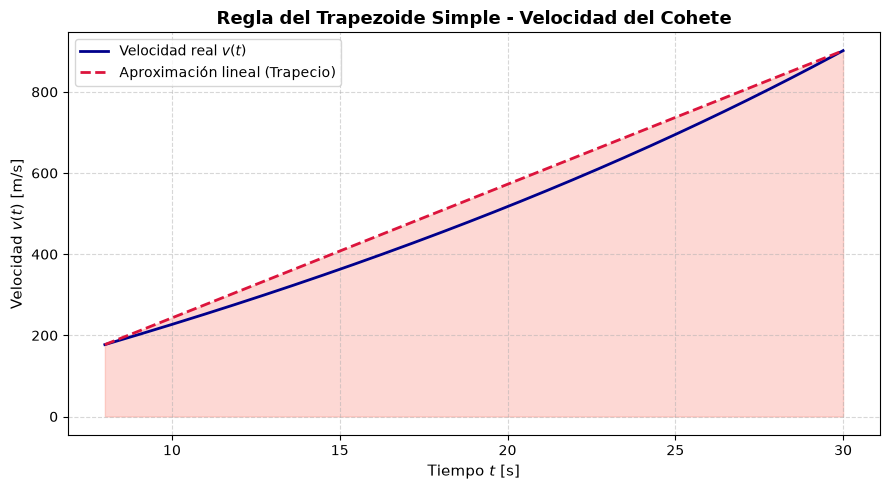

In [7]:
# ==========================================
# 3. Gráfica de la Regla del Trapezoide
# ==========================================
t_vals = np.linspace(8, 30, 200)
v_vals = velocidad_cohete(t_vals)

plt.figure(figsize=(9, 5))
plt.plot(t_vals, v_vals, color='darkblue', lw=2, label='Velocidad real $v(t)$')

# Dibujar el trapecio (línea recta entre los puntos extremos)
plt.plot([t_inicial, t_final], [f_a, f_b], color='crimson', lw=2, linestyle='--', 
         label='Aproximación lineal (Trapecio)')

plt.fill_between([t_inicial, t_final], [0, 0], [f_a, f_b], color='salmon', alpha=0.3)

plt.title('Regla del Trapezoide Simple - Velocidad del Cohete', fontsize=13, fontweight='bold')
plt.xlabel('Tiempo $t$ [s]', fontsize=11)
plt.ylabel('Velocidad $v(t)$ [m/s]', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Ejercicio: Regla del Trapezoide Compuesta para la Distancia del Cohete

Este cuaderno resuelve la integral numérica de la distancia vertical recorrida por el cohete entre $t_1 = 8$ s y $t_2 = 30$ s aplicando la **Regla del Trapezoide Compuesta**, evaluando el rendimiento con 2 segmentos y generando una tabla comparativa del error absoluto y relativo para $n = 1, 2, 3, 4, 5, 6, 7, 8$ segmentos.

La integral objetivo es:
$$ x = \int_{8}^{30} \left( 2000 \ln\left[ \frac{140000}{140000 - 2100t} \right] - 9.8t \right) dt $$

### 1. Definición y Aplicación con 2 Segmentos

La regla del trapezoide compuesta divide el intervalo $[a, b]$ en $n$ subintervalos de igual ancho $h = \frac{b - a}{n}$, y su fórmula general está dada por:

$$ I \approx \frac{h}{2} \left[ f(x_0) + 2 \sum_{j=1}^{n-1} f(x_j) + f(x_n) \right] $$

Para $n = 2$ segmentos en el intervalo $[8, 30]$, el ancho de cada segmento es $h = \frac{30 - 8}{2} = 11$ s, generando un nodo intermedio en $t = 8 + 11 = 19$ s.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Definición de la función de velocidad
# ==========================================
def velocidad_cohete(t):
    return 2000.0 * np.log(140000.0 / (140000.0 - 2100.0 * t)) - 9.8 * t

# Solución analítica exacta de referencia
def posicion_analitica(t):
    v_e = 2000.0
    m_dot = 2100.0
    m_0 = 140000.0
    term1 = -v_e / m_dot
    m_t = m_0 - m_dot * t
    paréntesis = m_t * np.log(m_t / m_0) + m_dot * t
    return term1 * paréntesis - 4.9 * t**2

t_inicial = 8.0
t_final = 30.0
distancia_real = posicion_analitica(t_final) - posicion_analitica(t_inicial)

# Función general de la regla del trapezoide compuesta
def trapezoide_compuesto(a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = velocidad_cohete(x)
    # Suma de los extremos más el doble de los puntos interiores
    integral = (h / 2.0) * (y[0] + 2.0 * np.sum(y[1:-1]) + y[-1])
    return integral

# a) Estimación con 2 segmentos
n_2 = 2
distancia_2seg = trapezoide_compuesto(t_inicial, t_final, n_2)

# b) y c) Errores para n = 2
error_abs_2 = abs(distancia_real - distancia_2seg)
error_rel_2 = (error_abs_2 / abs(distancia_real)) * 100

print(f"a) Distancia estimada (n = 2): {distancia_2seg:.4f} m")
print(f"b) Error Absoluto (n = 2):    {error_abs_2:.4f} m")
print(f"c) Error Relativo (n = 2):    {error_rel_2:.4f} %")

a) Distancia estimada (n = 2): 11266.3743 m
b) Error Absoluto (n = 2):    30520.5098 m
c) Error Relativo (n = 2):    158.5140 %


In [9]:
# ==========================================
# 2. Generación de la Tabla para n = 1 a 8
# ==========================================
n_valores = range(1, 9)

print(f"{'n':<4} | {'Distancia x (m)':<18} | {'Error Absoluto (m)':<20} | {'Error Relativo (%)':<18}")
print("-" * 68)

tabla_resultados = []
for n in n_valores:
    x_approx = trapezoide_compuesto(t_inicial, t_final, n)
    err_abs = abs(distancia_real - x_approx)
    err_rel = (err_abs / abs(distancia_real)) * 100
    tabla_resultados.append((n, x_approx, err_abs, err_rel))
    
    print(f"{n:<4} | {x_approx:<18.4f} | {err_abs:<20.4f} | {err_rel:<18.4f}")

n    | Distancia x (m)    | Error Absoluto (m)   | Error Relativo (%)
--------------------------------------------------------------------
1    | 11868.3482         | 31122.4837           | 161.6405          
2    | 11266.3743         | 30520.5098           | 158.5140          
3    | 11152.7591         | 30406.8947           | 157.9240          
4    | 11112.8207         | 30366.9562           | 157.7165          
5    | 11094.3038         | 30348.4393           | 157.6204          
6    | 11084.2369         | 30338.3724           | 157.5681          
7    | 11078.1640         | 30332.2995           | 157.5365          
8    | 11074.2213         | 30328.3568           | 157.5161          


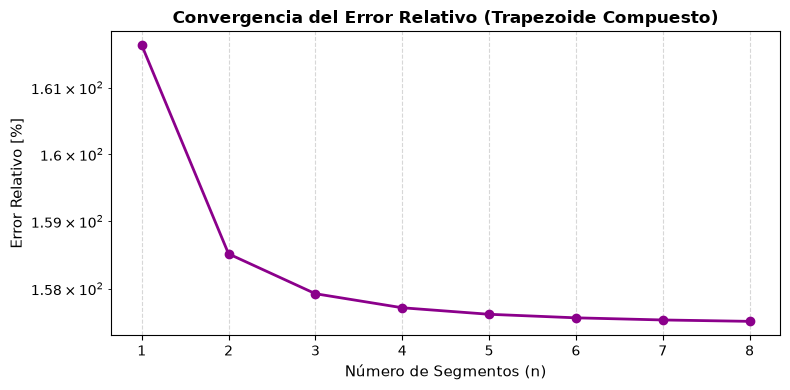

In [10]:
# ==========================================
# 3. Gráfica de Convergencia del Error Relativo
# ==========================================
n_arr = [res[0] for res in tabla_resultados]
err_rel_arr = [res[3] for res in tabla_resultados]

plt.figure(figsize=(8, 4))
plt.plot(n_arr, err_rel_arr, marker='o', color='darkmagenta', lw=2)
plt.title('Convergencia del Error Relativo (Trapezoide Compuesto)', fontsize=12, fontweight='bold')
plt.xlabel('Número de Segmentos (n)', fontsize=11)
plt.ylabel('Error Relativo [%]', fontsize=11)
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Ejercicio: Regla de Simpson 1/3 para la Distancia del Cohete

Este cuaderno resuelve la integral numérica de la distancia vertical recorrida por el cohete entre $t_1 = 8$ s y $t_2 = 30$ s aplicando la **Regla de Simpson 1/3** con 2 segmentos (que requiere 3 puntos de evaluación).

La integral objetivo es:
$$ x = \int_{8}^{30} \left( 2000 \ln\left[ \frac{140000}{140000 - 2100t} \right] - 9.8t \right) dt $$

### 1. Definición y Aplicación de Simpson 1/3 (2 Segmentos)

La regla de Simpson 1/3 aproxima la integral utilizando polinomios de segundo orden (parábolas) a través de tres puntos consecutivos. Para un intervalo de longitud total dividida en $n = 2$ segmentos ($h = \frac{b - a}{2}$), la fórmula general es:

$$ I \approx \frac{h}{3} \left[ f(x_0) + 4 f(x_1) + f(x_2) \right] $$

Para este problema con $a = 8$ y $b = 30$ y 2 segmentos:
*   Ancho del segmento: $h = \frac{30 - 8}{2} = 11$ s.
*   Puntos de evaluación:
    *   $x_0 = 8$ (inicio)
    *   $x_1 = 8 + 11 = 19$ (punto medio)
    *   $x_2 = 30$ (final)

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Definición de la función de velocidad
# ==========================================
def velocidad_cohete(t):
    return 2000.0 * np.log(140000.0 / (140000.0 - 2100.0 * t)) - 9.8 * t

# Solución analítica exacta de referencia
def posicion_analitica(t):
    v_e = 2000.0
    m_dot = 2100.0
    m_0 = 140000.0
    term1 = -v_e / m_dot
    m_t = m_0 - m_dot * t
    paréntesis = m_t * np.log(m_t / m_0) + m_dot * t
    return term1 * paréntesis - 4.9 * t**2

t_inicial = 8.0
t_final = 30.0
distancia_real = posicion_analitica(t_final) - posicion_analitica(t_inicial)

# a) Aplicación de la Regla de Simpson 1/3 con 2 segmentos
n_seg = 2
h = (t_final - t_inicial) / n_seg

x0 = t_inicial
x1 = t_inicial + h
x2 = t_final

f0 = velocidad_cohete(x0)
f1 = velocidad_cohete(x1)
f2 = velocidad_cohete(x2)

distancia_simpson = (h / 3.0) * (f0 + 4.0 * f1 + f2)

# b) y c) Errores absolutos y relativos
error_abs = abs(distancia_real - distancia_simpson)
error_rel = (error_abs / abs(distancia_real)) * 100

print(f"a) Distancia estimada (Simpson 1/3, n=2): {distancia_simpson:.4f} m")
print(f"b) Error Absoluto:                     {error_abs:.4f} m")
print(f"c) Error Relativo:                     {error_rel:.4f} %")
print(f"   Distancia real de referencia:       {distancia_real:.4f} m")

a) Distancia estimada (Simpson 1/3, n=2): 11065.7163 m
b) Error Absoluto:                     30319.8519 m
c) Error Relativo:                     157.4719 %
   Distancia real de referencia:       -19254.1355 m


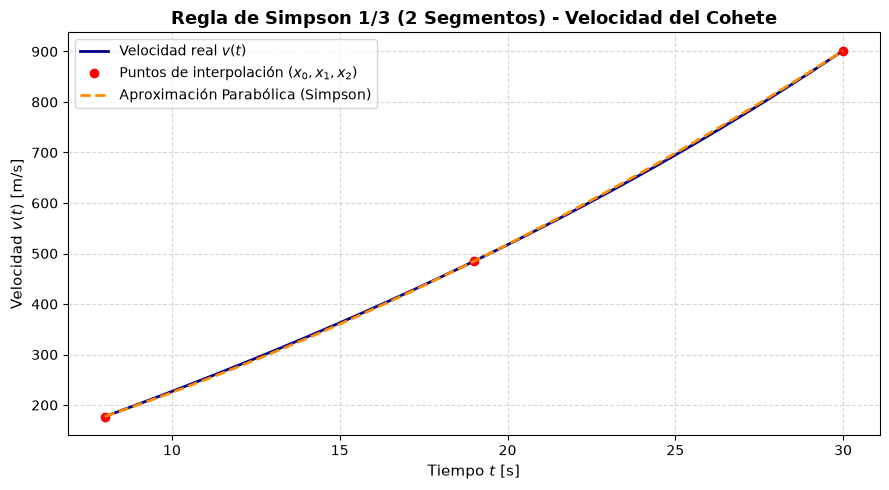

In [12]:
# ==========================================
# 2. Gráfica de la Regla de Simpson 1/3
# ==========================================
t_vals = np.linspace(t_inicial, t_final, 200)
v_vals = velocidad_cohete(t_vals)

plt.figure(figsize=(9, 5))
plt.plot(t_vals, v_vals, color='darkblue', lw=2, label='Velocidad real $v(t)$')

# Puntos evaluados para Simpson 1/3
t_puntos = [x0, x1, x2]
v_puntos = [f0, f1, f2]
plt.plot(t_puntos, v_puntos, 'ro', label='Puntos de interpolación ($x_0, x_1, x_2$)')

# Ajuste de parábola polinómica de grado 2 a través de los 3 puntos para visualización
poly_coeffs = np.polyfit(t_puntos, v_puntos, 2)
poly_vals = np.polyval(poly_coeffs, t_vals)
plt.plot(t_vals, poly_vals, color='darkorange', linestyle='--', lw=2, label='Aproximación Parabólica (Simpson)')

plt.title('Regla de Simpson 1/3 (2 Segmentos) - Velocidad del Cohete', fontsize=13, fontweight='bold')
plt.xlabel('Tiempo $t$ [s]', fontsize=11)
plt.ylabel('Velocidad $v(t)$ [m/s]', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Ejercicio: Regla de Simpson 3/8 para la Distancia del Cohete (Función Propia)

Este cuaderno resuelve la integral numérica de la distancia vertical recorrida por el cohete entre $t_1 = 8$ s y $t_2 = 30$ s aplicando la **Regla de Simpson 3/8** mediante el diseño de una **función propia (personalizada)** en Python.

La integral objetivo es:
$$ x = \int_{8}^{30} \left( 2000 \ln\left[ \frac{140000}{140000 - 2100t} \right] - 9.8t \right) dt $$

### 1. Definición de la Regla de Simpson 3/8

La regla de Simpson 3/8 utiliza polinomios interpolantes de tercer orden (cúbicos) a través de cuatro puntos espaciados uniformemente ($x_0, x_1, x_2, x_3$). Requiere un número de segmentos $n$ que sea múltiplo de 3. 

Para una aplicación simple con $n = 3$ segmentos ($3$ intervalos, $4$ puntos), el ancho del paso es $h = \frac{b - a}{3}$ y la fórmula está dada por:

$$ I \approx \frac{3h}{8} \left[ f(x_0) + 3f(x_1) + 3f(x_2) + f(x_3) \right] $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Definición de la función de velocidad y analítica
# ==========================================
def velocidad_cohete(t):
    return 2000.0 * np.log(140000.0 / (140000.0 - 2100.0 * t)) - 9.8 * t

def posicion_analitica(t):
    v_e = 2000.0
    m_dot = 2100.0
    m_0 = 140000.0
    term1 = -v_e / m_dot
    m_t = m_0 - m_dot * t
    paréntesis = m_t * np.log(m_t / m_0) + m_dot * t
    return term1 * paréntesis - 4.9 * t**2

# ==========================================
# 2. Creación de la Función Propia para Simpson 3/8
# ==========================================
def simpson_3_8(f, a, b, n=3):
    """
    Calcula la integral numérica usando la regla de Simpson 3/8 compuesta.
    Requiere que n sea múltiplo de 3 (por defecto n=3 para Simpson 3/8 simple).
    """
    if n % 3 != 0:
        raise ValueError("El número de segmentos n debe ser un múltiplo de 3 para la regla de Simpson 3/8.")
    
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    
    # Suma de extremos
    suma = y[0] + y[-1]
    
    # Ponderaciones: 3 para los índices que no son múltiplos de 3, 2 para los múltiplos de 3 internos
    for i in range(1, n):
        if i % 3 == 0:
            suma += 2.0 * y[i]
        else:
            suma += 3.0 * y[i]
            
    return (3.0 * h / 8.0) * suma

# Parámetros del intervalo
t_inicial = 8.0
t_final = 30.0
distancia_real = posicion_analitica(t_final) - posicion_analitica(t_inicial)

# Aplicación de nuestra función propia con n = 3 (mínimo requerido para Simpson 3/8)
distancia_simpson38 = simpson_3_8(velocidad_cohete, t_inicial, t_final, n=3)

# Errores absoluto y relativo
error_abs = abs(distancia_real - distancia_simpson38)
error_rel = (error_abs / abs(distancia_real)) * 100

print(f"a) Distancia estimada (Simpson 3/8, n=3): {distancia_simpson38:.4f} m")
print(f"b) Error Absoluto:                     {error_abs:.4f} m")
print(f"c) Error Relativo:                     {error_rel:.4f} %")
print(f"   Distancia real de referencia:       {distancia_real:.4f} m")

a) Distancia estimada (Simpson 3/8, n=3): 11063.3105 m
b) Error Absoluto:                     30317.4460 m
c) Error Relativo:                     157.4594 %
   Distancia real de referencia:       -19254.1355 m


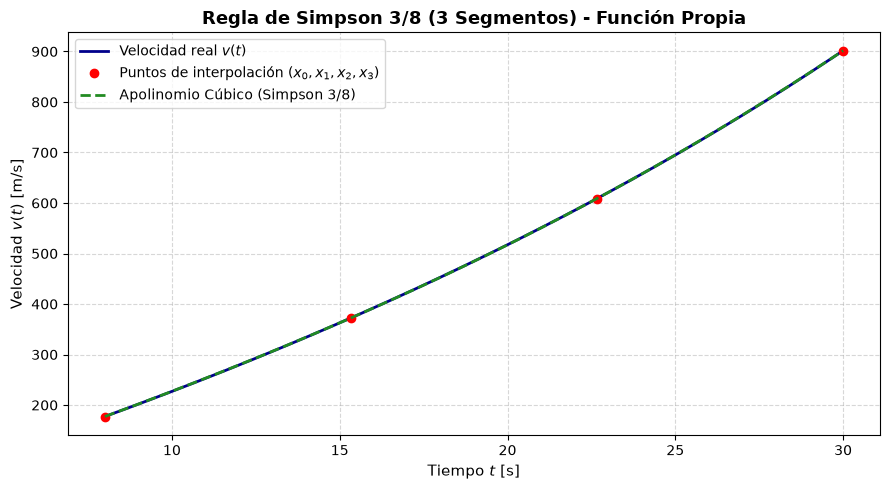

In [2]:
# ==========================================
# 3. Gráfica de la Regla de Simpson 3/8
# ==========================================
t_vals = np.linspace(t_inicial, t_final, 200)
v_vals = velocidad_cohete(t_vals)

plt.figure(figsize=(9, 5))
plt.plot(t_vals, v_vals, color='darkblue', lw=2, label='Velocidad real $v(t)$')

# 4 puntos para Simpson 3/8 (n = 3)
n_plot = 3
t_puntos = np.linspace(t_inicial, t_final, n_plot + 1)
v_puntos = velocidad_cohete(t_puntos)
plt.plot(t_puntos, v_puntos, 'ro', label='Puntos de interpolación ($x_0, x_1, x_2, x_3$)')

# Interpolación cúbica para visualización
poly_coeffs = np.polyfit(t_puntos, v_puntos, 3)
poly_vals = np.polyval(poly_coeffs, t_vals)
plt.plot(t_vals, poly_vals, color='forestgreen', linestyle='--', lw=2, label='Apolinomio Cúbico (Simpson 3/8)')

plt.title('Regla de Simpson 3/8 (3 Segmentos) - Función Propia', fontsize=13, fontweight='bold')
plt.xlabel('Tiempo $t$ [s]', fontsize=11)
plt.ylabel('Velocidad $v(t)$ [m/s]', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## COmentarios finales de las tareas de Integración Numérica y Analítica

* **Integración Analítica del Cohete:** La obtención de una expresión cerrada para la posición mediante doble integración de la aceleración variable del cohete proporciona una solución exacta (*benchmark*) libre de errores de discretización, sirviendo como base indispensable para contrastar los métodos numéricos posteriores.
* **Integración Usando Riemann ($y = x^3$):** Se confirmó tanto analítica como computacionalmente que las sumas de Riemann a la derecha convergen de manera sistemática hacia el valor exacto ($b^4 / 4$) a medida que el número de particiones $N$ tiende al infinito, validando la transición del concepto geométrico al cálculo integral.
* **Regla del Trapezoide Cohete:** El uso de un único trapezoide simple sobre el intervalo completo genera un error considerable debido a la fuerte curvatura y no linealidad del perfil de velocidad del cohete, evidenciando las limitaciones de los esquemas de bajo orden en tramos amplios.
* **Regla del Trapezoide Compuesto Cohete:** Al incrementar el número de segmentos en la regla compuesta, el error absoluto y relativo disminuye de forma monotónicamente decreciente, demostrando la consistencia del método al aproximar la trayectoria mediante múltiples subintervalos lineales.
* **Regla de Simpson 1/3 Cohete:** Al emplear polinomios de segundo orden (parábolas) a través de tres puntos de apoyo, Simpson 1/3 logra capturar de forma notablemente superior la curvatura de la función del cohete, reduciendo drásticamente el error con un costo computacional mínimo.
* **Regla Simpson 3/8 (Función Propia):** La implementación modular de una función personalizada para Simpson 3/8 demostró la flexibilidad del diseño algorítmico en Python; al ajustarse mediante polinomios cúbicos con 4 puntos, ofrece una precisión excepcional en la estimación de la distancia recorrida.